In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("final_dataset.csv")

In [3]:
df.head(20)

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm
5,"I, for one, am thrilled that Christ works outs...",happiness
6,i hate that she has the power to make me feel ...,hate
7,i feel like i missed it,neutral
8,i have personally experienced this gut wrenchi...,sadness
9,i hate feeling that people see me as ugly but ...,hate


In [4]:
df['emotion'].value_counts()

emotion
fun           10000
surprise      10000
enthusiasm    10000
happiness     10000
hate          10000
love          10000
relief        10000
anger         10000
sadness        9999
neutral        9998
empty          6358
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

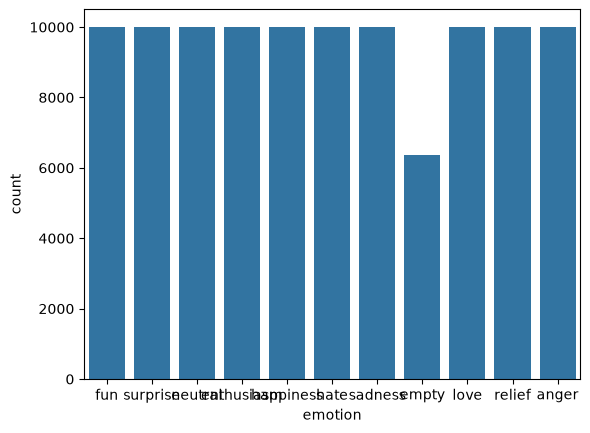

In [5]:
sns.countplot(x='emotion',data=df)

In [6]:
#remove the user handles
import re

df['Clean_Text'] = df['text'].apply(lambda x: re.sub(r'@\w+', '', str(x)))

In [7]:
dir(re)

['A',
 'ASCII',
 'DEBUG',
 'DOTALL',
 'I',
 'IGNORECASE',
 'L',
 'LOCALE',
 'M',
 'MULTILINE',
 'Match',
 'NOFLAG',
 'Pattern',
 'RegexFlag',
 'S',
 'Scanner',
 'T',
 'TEMPLATE',
 'U',
 'UNICODE',
 'VERBOSE',
 'X',
 '_MAXCACHE',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_cache',
 '_casefix',
 '_compile',
 '_compile_repl',
 '_compiler',
 '_constants',
 '_expand',
 '_parser',
 '_pickle',
 '_special_chars_map',
 '_subx',
 'compile',
 'copyreg',
 'enum',
 'error',
 'escape',
 'findall',
 'finditer',
 'fullmatch',
 'functools',
 'match',
 'purge',
 'search',
 'split',
 'sub',
 'subn',
 'template']

In [8]:
#Remove the stopwords
from nltk.corpus import stopwords
import nltk

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

In [9]:
df

,text,emotion,Clean_Text
0,i feel rather funny ending with so many dupes ...,fun,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result,surprise,i feel surprised by the result
2,i am officially feeling festive,neutral,i am officially feeling festive
3,i suddenly found myself standing before this w...,surprise,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...,enthusiasm,i look at the meager pile of food i purchased ...
...,...,...,...
106350,i used to feel strongly about how much i hated...,hate,i used to feel strongly about how much i hated...
106351,i feel like i just got a spirit booster this r...,surprise,i feel like i just got a spirit booster this r...
106352,i could come up with is that i was really feel...,anger,i could come up with is that i was really feel...
106353,i find it really it helps to have an outfit of...,relief,i find it really it helps to have an outfit of...


In [10]:
x=df['Clean_Text']
y=df['emotion']

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [13]:
pipe_lr=Pipeline(steps=[('cv',CountVectorizer()),('lr',LogisticRegression(max_iter=1000))])
pipe_lr.fit(x_train,y_train)
pipe_lr.score(x_test,y_test)

0.8537938383426834

In [14]:
from sklearn.svm import LinearSVC

pipe_svm = Pipeline(steps=[
    ('cv', CountVectorizer(max_features=10000)),
    ('svc', LinearSVC())
])

pipe_svm.fit(x_train, y_train)
print(pipe_svm.score(x_test, y_test))

0.8429811640078979


In [15]:
pipe_rf=Pipeline(steps=[('cv',CountVectorizer()),('rf',RandomForestClassifier(n_estimators=10))])
pipe_rf.fit(x_train,y_train)
pipe_rf.score(x_test,y_test)

0.7650358855423575

In [17]:
#saving the model

import joblib
pipeline_file=open("text_emotion.pkl","wb")
joblib.dump(pipe_lr,pipeline_file)
pipeline_file.close()